
# Code for the Paper - Readmission Prevention in Healthcare Using AI

This notebook accompanies the manuscript *Readmission Prevention in Healthcare Using AI*. It implements a facility-level risk stratification workflow using publicly available Centers for Medicare & Medicaid Services (CMS) hospital data.

The analysis identifies hospitals at elevated risk of excess readmission using interpretable machine learning. The primary outcome is facility-level high-risk status, defined as mean Excess Readmission Ratio (ERR) >= 1.0 after aggregation across reported HRRP measures.

Notebook structure:

1. Environment setup and data loading
2. Data cleaning, integration, and facility-level aggregation
3. Descriptive readmission analysis
4. Visualization of readmission distributions and institutional patterns
5. Model development, baseline comparisons, and hold-out evaluation
6. Sensitivity analyses and EBM interpretability
7. Export of manuscript-ready tables and figures


# 1. Setup and Import Libraries


The below code imports essential libraries (pandas, numpy, matplotlib, seaborn, scipy, and sklearn) and configures display and plotting settings for a data analysis environment.

In [1]:
%pip install -q interpret xgboost seaborn


In [2]:
# Core data and plotting libraries
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier
from interpret.glassbox import ExplainableBoostingClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

print("Libraries imported successfully")

Libraries imported successfully


# 2. Loading the Data


Load the CMS source files used in the manuscript: HRRP readmissions, Hospital General Information, HCAHPS, Healthcare-Associated Infections, and Complications and Deaths.


In [3]:
# Specify the locations of each dataset file
file_paths = {
    'readmissions': 'Hospital_Readmissions.csv',
    'hospital_info': 'Hospital_General_Information.csv',
    'hai': 'Healthcare_Associated_Infections.csv',
    'hcahps': 'HCAHPS_Hospital.csv',
    'mortality': 'Complications_and_Deaths.csv'
}

# Function to read and load all CMS datasets into memory
def load_cms_data(file_paths):
    """Load all CMS datasets from CSV paths.

    Returns a dict of DataFrames keyed by dataset name.
    Missing files are reported and set to None.
    """
    datasets = {}

    for name, path in file_paths.items():
        try:
            datasets[name] = pd.read_csv(path, low_memory=False)
            print(f"{name}: {datasets[name].shape} - {datasets[name].shape[0]:,} rows, {datasets[name].shape[1]} columns")
        except FileNotFoundError:
            print(f"{name}: File not found at {path}")
            datasets[name] = None

    return datasets

# Execute the loading process and store results
data = load_cms_data(file_paths)

# Extract each dataset into its own named variable for easier access
readmissions = data['readmissions']
hospital_info = data['hospital_info']
hai = data['hai']
hcahps = data['hcahps']
mortality = data['mortality']

readmissions: (18510, 12) - 18,510 rows, 12 columns
hospital_info: (5421, 38) - 5,421 rows, 38 columns
hai: (172476, 15) - 172,476 rows, 15 columns
hcahps: (445563, 22) - 445,563 rows, 22 columns
mortality: (95820, 18) - 95,820 rows, 18 columns


# 3. Data Cleaning and Preparation


Standardize missing-value placeholders, convert numeric fields, and remove duplicate rows while preserving the original input tables.


In [4]:
def clean_readmission_data(df):
    """Clean and prepare readmission data"""

    if df is None:
        print("No data to clean")
        return None

    df_clean = df.copy()

    # Substitute common placeholder text with NaN values
    replacements = ['Not Available', 'Too Few to Report', 'N/A', '']
    for val in replacements:
        df_clean = df_clean.replace(val, np.nan)

    # Identify and convert columns containing numerical data to the correct type
    numeric_patterns = ['Ratio', 'Rate', 'Number', 'Score', 'Count']

    for col in df_clean.columns:
        if any(pattern in col for pattern in numeric_patterns):
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    # Eliminate any repeated rows from the dataset
    before_dup = len(df_clean)
    df_clean = df_clean.drop_duplicates()
    after_dup = len(df_clean)

    print(f"Data cleaned")
    print(f"  - Removed {before_dup - after_dup} duplicate rows")
    print(f"  - Final shape: {df_clean.shape}")
    print(f"\n  Missing values by column:")
    missing = df_clean.isnull().sum()
    missing_pct = (missing / len(df_clean) * 100).round(1)
    missing_df = pd.DataFrame({
        'Missing': missing[missing > 0],
        'Percent': missing_pct[missing > 0]
    }).sort_values('Missing', ascending=False)
    display(missing_df.head(10))

    return df_clean

# Apply the cleaning process to the readmissions dataset
readmissions_clean = clean_readmission_data(readmissions)

Data cleaned
  - Removed 0 duplicate rows
  - Final shape: (18510, 12)

  Missing values by column:


,Missing,Percent
Footnote,11927,64.4
Number of Readmissions,10389,56.1
Number of Discharges,10170,54.9
Excess Readmission Ratio,6583,35.6
Predicted Readmission Rate,6583,35.6
Expected Readmission Rate,6583,35.6


# 4. Data Integration and Facility-Level Analysis


Merge readmission records with hospital attributes using facility identifiers. The integrated table supports descriptive analysis and facility-level model construction.


In [5]:
def merge_datasets(df1, df2, left_on='Facility ID', right_on='Provider ID'):
    """Merge two datasets on hospital identifier"""

    if df1 is None or df2 is None:
        print("Cannot merge: One or both datasets are missing")
        return None

    # Create copies to preserve the original datasets
    df1_copy = df1.copy()
    df2_copy = df2.copy()

    # Check if the right key exists, otherwise default to Facility ID
    right_key = right_on if right_on in df2.columns else 'Facility ID'

    # Normalize the hospital ID field for a consistent merge key
    if left_on in df1_copy.columns:
        df1_copy['Hospital_ID'] = df1_copy[left_on].astype(str).str.strip()
    if right_key in df2_copy.columns:
        df2_copy['Hospital_ID'] = df2_copy[right_key].astype(str).str.strip()

    # Combine both datasets using the shared hospital identifier
    merged = pd.merge(df1_copy, df2_copy,
                     on='Hospital_ID',
                     how='inner',
                     suffixes=('_readmit', '_info'))

    print(f"Datasets merged successfully")
    print(f"  - Left dataset: {len(df1):,} rows")
    print(f"  - Right dataset: {len(df2):,} rows")
    print(f"  - Merged dataset: {len(merged):,} rows ({len(merged)/len(df1)*100:.1f}% match rate)")
    print(f"  - Total columns: {merged.shape[1]}")
    print(f"  - Unique source facilities: {df1_copy['Hospital_ID'].nunique():,}")
    print(f"  - Unique merged facilities: {merged['Hospital_ID'].nunique():,}")
    print(f"  - Unmatched readmission rows dropped by inner join: {len(df1) - len(merged):,}")

    return merged

# Combine readmissions and hospital information into a single master table
master_data = merge_datasets(readmissions_clean, hospital_info,
                            left_on='Facility ID', right_on='Provider ID')

if master_data is not None:
    display(master_data.head())

Datasets merged successfully
  - Left dataset: 18,510 rows
  - Right dataset: 5,421 rows
  - Merged dataset: 14,910 rows (80.6% match rate)
  - Total columns: 51
  - Unique source facilities: 3,085
  - Unique merged facilities: 2,485
  - Unmatched readmission rows dropped by inner join: 3,600


,Facility Name_readmit,Facility ID_readmit,State_readmit,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date,Hospital_ID,Facility ID_info,Facility Name_info,Address,City/Town,State_info,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,Emergency Services,Meets criteria for birthing friendly designation,Hospital overall rating,Hospital overall rating footnote,MORT Group Measure Count,Count of Facility MORT Measures,Count of MORT Measures Better,Count of MORT Measures No Different,Count of MORT Measures Worse,MORT Group Footnote,Safety Group Measure Count,Count of Facility Safety Measures,Count of Safety Measures Better,Count of Safety Measures No Different,Count of Safety Measures Worse,Safety Group Footnote,READM Group Measure Count,Count of Facility READM Measures,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,SHANDS JACKSONVILLE,100001,FL,READM-30-PN-HRRP,240.0,NaN,1.0077,18.9435,18.7994,46.0,07/01/2020,06/30/2023,100001,100001,SHANDS JACKSONVILLE,655 W 8TH ST,JACKSONVILLE,FL,32209,DUVAL,(904) 244-4000,Acute Care Hospitals,Voluntary non-profit - Private,Yes,Y,3,NaN,7,7,0,7,0,NaN,8,7,1,6,0,NaN,11,10,0,10,0,NaN,8,8,NaN,12,11,NaN
1,SHANDS JACKSONVILLE,100001,FL,READM-30-HIP-KNEE-HRRP,NaN,1.0,NaN,NaN,NaN,NaN,07/01/2020,06/30/2023,100001,100001,SHANDS JACKSONVILLE,655 W 8TH ST,JACKSONVILLE,FL,32209,DUVAL,(904) 244-4000,Acute Care Hospitals,Voluntary non-profit - Private,Yes,Y,3,NaN,7,7,0,7,0,NaN,8,7,1,6,0,NaN,11,10,0,10,0,NaN,8,8,NaN,12,11,NaN
2,SHANDS JACKSONVILLE,100001,FL,READM-30-HF-HRRP,430.0,NaN,0.9639,20.3806,21.1444,85.0,07/01/2020,06/30/2023,100001,100001,SHANDS JACKSONVILLE,655 W 8TH ST,JACKSONVILLE,FL,32209,DUVAL,(904) 244-4000,Acute Care Hospitals,Voluntary non-profit - Private,Yes,Y,3,NaN,7,7,0,7,0,NaN,8,7,1,6,0,NaN,11,10,0,10,0,NaN,8,8,NaN,12,11,NaN
3,SHANDS JACKSONVILLE,100001,FL,READM-30-COPD-HRRP,119.0,NaN,1.1418,24.4220,21.3887,38.0,07/01/2020,06/30/2023,100001,100001,SHANDS JACKSONVILLE,655 W 8TH ST,JACKSONVILLE,FL,32209,DUVAL,(904) 244-4000,Acute Care Hospitals,Voluntary non-profit - Private,Yes,Y,3,NaN,7,7,0,7,0,NaN,8,7,1,6,0,NaN,11,10,0,10,0,NaN,8,8,NaN,12,11,NaN
4,SHANDS JACKSONVILLE,100001,FL,READM-30-CABG-HRRP,NaN,NaN,0.9958,10.9852,11.0320,NaN,07/01/2020,06/30/2023,100001,100001,SHANDS JACKSONVILLE,655 W 8TH ST,JACKSONVILLE,FL,32209,DUVAL,(904) 244-4000,Acute Care Hospitals,Voluntary non-profit - Private,Yes,Y,3,NaN,7,7,0,7,0,NaN,8,7,1,6,0,NaN,11,10,0,10,0,NaN,8,8,NaN,12,11,NaN


# 4.1 Readmission Performance by Institutional Characteristics


Summarize ERR by hospital type, ownership, and CMS overall rating to characterize institutional gradients in readmission performance.


In [6]:
# Examine how readmission performance varies across hospital type, ownership, and star rating
# Note: master_data operates at measure level (one row per hospital x measure x period)
if master_data is not None and 'Excess Readmission Ratio' in master_data.columns:
    ratio_col = 'Excess Readmission Ratio'

    # Summarize average readmission ratios grouped by hospital type
    type_col = 'Hospital Type' if 'Hospital Type' in master_data.columns else None
    if type_col:
        by_type = master_data.groupby(type_col)[ratio_col].agg(['mean', 'std', 'count']).round(4).sort_values('mean')
        print("Excess Readmission Ratio by Hospital Type")
        print("=" * 60)
        display(by_type)

    # Summarize average readmission ratios grouped by ownership category
    own_col = 'Hospital Ownership' if 'Hospital Ownership' in master_data.columns else None
    if own_col:
        by_own = master_data.groupby(own_col)[ratio_col].agg(['mean', 'std', 'count']).round(4).sort_values('mean')
        print("\nExcess Readmission Ratio by Hospital Ownership")
        print("=" * 60)
        display(by_own)

    # Arrange and display readmission ratios ordered by numerical star rating
    rating_col = 'Hospital overall rating' if 'Hospital overall rating' in master_data.columns else None
    if rating_col:
        master_data['_rating_num'] = pd.to_numeric(master_data[rating_col], errors='coerce')
        by_rating = master_data.dropna(subset=['_rating_num']).groupby(rating_col)[ratio_col].agg(['mean', 'std', 'count']).round(4)
        by_rating = by_rating.reindex(sorted(by_rating.index, key=lambda x: (pd.to_numeric(x, errors='coerce') if str(x).isdigit() else 99)))
        print("\nExcess Readmission Ratio by Hospital overall rating")
        print("=" * 60)
        display(by_rating)
        master_data.drop(columns=['_rating_num'], inplace=True, errors='ignore')

Excess Readmission Ratio by Hospital Type


,mean,std,count
Hospital Type,,,
Acute Care Hospitals,1.0013,0.0804,9794



Excess Readmission Ratio by Hospital Ownership


,mean,std,count
Hospital Ownership,,,
Physician,0.9532,0.1423,79
Tribal,0.9658,0.0202,3
Voluntary non-profit - Church,0.9934,0.0764,807
Government - Federal,0.9940,0.0529,28
Government - Local,0.9967,0.0712,406
Voluntary non-profit - Other,0.9972,0.0761,818
Government - Hospital District or Authority,0.9986,0.0702,619
Voluntary non-profit - Private,0.9996,0.0812,5238
Government - State,1.0026,0.0766,144



Excess Readmission Ratio by Hospital overall rating


,mean,std,count
Hospital overall rating,,,
1,1.0469,0.0817,724
2,1.0214,0.0802,2222
3,1.0046,0.0741,3029
4,0.9818,0.0762,2568
5,0.9645,0.0789,802


# 4.2 Reporting Period Audit


Audit the CMS reporting windows represented in the readmission data and summarize average ERR by period when multiple periods are available.


In [7]:
#Investigate how average readmission ratios shift across different reporting periods
if master_data is not None and 'Excess Readmission Ratio' in master_data.columns:
    start_col = 'Start Date' if 'Start Date' in master_data.columns else None
    end_col = 'End Date' if 'End Date' in master_data.columns else None
    ratio_col = 'Excess Readmission Ratio'

    if start_col and end_col:
        periods = master_data[[start_col, end_col]].drop_duplicates()
        print("Unique reporting periods (Start Date / End Date):")
        print("=" * 50)
        display(periods)
        print(f"\nNumber of unique periods: {len(periods)}")

        # Calculate average readmission ratio for each individual reporting window
        by_period = master_data.groupby([start_col, end_col])[ratio_col].agg(['mean', 'std', 'count']).round(4)
        print("\nExcess Readmission Ratio by period (mean, SD, N):")
        print("=" * 50)
        display(by_period)
    else:
        print("Start Date or End Date column not found in merged data.")

Unique reporting periods (Start Date / End Date):


,Start Date,End Date
0,07/01/2020,06/30/2023



Number of unique periods: 1

Excess Readmission Ratio by period (mean, SD, N):


,,mean,std,count
Start Date,End Date,,,
07/01/2020,06/30/2023,1.0013,0.0804,9794


# 5. Descriptive Statistics


Compute descriptive statistics for the manuscript's core readmission variables, including ERR, number of readmissions, and number of discharges.


In [8]:
def comprehensive_stats(df, variables):
    """Calculate comprehensive descriptive statistics"""

    stats_list = []

    for var in variables:
        if var not in df.columns:
            continue

        stats_dict = {
            'Variable': var,
            'N': df[var].count(),
            'Missing': df[var].isnull().sum(),
            'Mean': df[var].mean(),
            'SD': df[var].std(),
            'Median': df[var].median(),
            'Q1': df[var].quantile(0.25),
            'Q3': df[var].quantile(0.75),
            'Min': df[var].min(),
            'Max': df[var].max()
        }
        stats_list.append(stats_dict)

    stats_df = pd.DataFrame(stats_list)

    # Round all numerical columns to two decimal places for cleaner presentation
    numeric_cols = ['Mean', 'SD', 'Median', 'Q1', 'Q3', 'Min', 'Max']
    for col in numeric_cols:
        stats_df[col] = stats_df[col].round(2)

    return stats_df

# Specify the key variables to be statistically summarized
key_variables = [
    'Excess Readmission Ratio',
    'Number of Readmissions',
    'Number of Discharges'
]

if master_data is not None:
    desc_stats = comprehensive_stats(master_data, key_variables)
    print("\nDESCRIPTIVE STATISTICS (Table 1)")
    print("=" * 100)
    display(desc_stats)


DESCRIPTIVE STATISTICS (Table 1)


,Variable,N,Missing,Mean,SD,Median,Q1,Q3,Min,Max
0,Excess Readmission Ratio,9794,5116,1.00,0.08,1.0,0.96,1.04,0.55,1.56
1,Number of Readmissions,6758,8152,48.82,49.67,32.0,19.00,60.00,11.00,877.00
2,Number of Discharges,6914,7996,284.96,271.34,200.0,117.00,362.00,0.00,4501.00


# 5.1 Readmission Performance by Clinical Measure


Reproduce the manuscript's descriptive ERR summaries by clinical measure and benchmark status.


In [9]:
# Reproduce key readmission statistics and breakdowns by clinical measure
if master_data is not None and 'Excess Readmission Ratio' in master_data.columns:
    ratio_col = 'Excess Readmission Ratio'
    measure_col = 'Measure Name' if 'Measure Name' in master_data.columns else None

    # Extract and display core descriptive statistics for the Excess Readmission Ratio
    err = master_data[ratio_col].dropna()
    print("Excess Readmission Ratio - key descriptive statistics")
    print("=" * 55)
    print(f"  N:      {len(err):,}")
    print(f"  Mean:   {err.mean():.4f}")
    print(f"  SD:     {err.std():.4f}")
    print(f"  Median: {err.median():.4f}")
    print(f"  Min:    {err.min():.4f}")
    print(f"  Max:    {err.max():.4f}")
    print(f"  Q1:     {err.quantile(0.25):.4f}")
    print(f"  Q3:     {err.quantile(0.75):.4f}")

    # Break down average readmission ratios by individual clinical measure
    if measure_col:
        by_measure = master_data.groupby(measure_col)[ratio_col].agg(['mean', 'std', 'count']).round(4)
        by_measure.columns = ['Mean ratio', 'SD', 'N (numeric)']
        print("\nExcess Readmission Ratio by clinical measure")
        print("=" * 55)
        display(by_measure)

    # Categorize hospitals as performing better or worse than the expected benchmark
    below = (master_data[ratio_col] < 1).sum()
    above = (master_data[ratio_col] >= 1).sum()
    valid = master_data[ratio_col].notna().sum()
    print(f"\nBetter than expected (ratio < 1): {below:,} ({100*below/valid:.1f}%)")
    print(f"At or above expected (ratio >= 1): {above:,} ({100*above/valid:.1f}%)")

Excess Readmission Ratio - key descriptive statistics
  N:      9,794
  Mean:   1.0013
  SD:     0.0804
  Median: 0.9975
  Min:    0.5534
  Max:    1.5629
  Q1:     0.9555
  Q3:     1.0429

Excess Readmission Ratio by clinical measure


,Mean ratio,SD,N (numeric)
Measure Name,,,
READM-30-AMI-HRRP,1.0017,0.0719,1461
READM-30-CABG-HRRP,0.9989,0.0811,718
READM-30-COPD-HRRP,1.0023,0.0538,1929
READM-30-HF-HRRP,0.9998,0.0674,2152
READM-30-HIP-KNEE-HRRP,1.0067,0.1425,1309
READM-30-PN-HRRP,0.9993,0.0638,2225



Better than expected (ratio < 1): 5,057 (51.6%)
At or above expected (ratio >= 1): 4,737 (48.4%)


# 6. Data Visualization


# 6.1 Distribution of Readmission Ratios


Generate the manuscript distribution figure for facility-measure ERR values, including mean and median reference lines.


No. of Observations =  9794
Mean =  1.0013083112109455
Median =  0.9975
STD =  0.08040370250581291


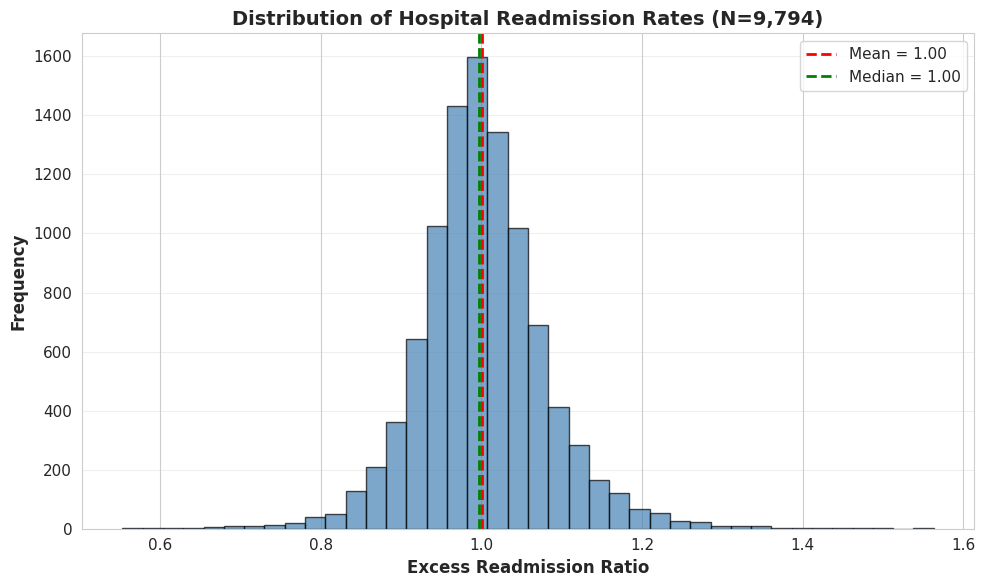

Figure saved: Figure1_Readmission_Distribution.png


In [10]:

# Figure 1: Distribution histogram
if master_data is not None and 'Excess Readmission Ratio' in master_data.columns:

    fig, ax = plt.subplots(figsize=(10, 6))

    data_to_plot = master_data['Excess Readmission Ratio'].dropna()

    # Plot the distribution with mean and median reference lines overlaid
    ax.hist(data_to_plot, bins=40, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(data_to_plot.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {data_to_plot.mean():.2f}')
    ax.axvline(data_to_plot.median(), color='green', linestyle='--', linewidth=2, label=f'Median = {data_to_plot.median():.2f}')

    # Apply axis labels, title, and formatting for a publication ready figure
    ax.set_xlabel('Excess Readmission Ratio', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_title('Distribution of Hospital Readmission Rates (N={:,})'.format(len(data_to_plot)),
                fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    print("No. of Observations = ", len(data_to_plot))
    print("Mean = ", data_to_plot.mean())
    print("Median = ", data_to_plot.median())
    print("STD = ", data_to_plot.std())

   # Export the completed figure as a high resolution image file
    plt.tight_layout()
    plt.savefig('Figure1_Readmission_Distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Figure saved: Figure1_Readmission_Distribution.png")


# 6.2 Readmission Ratios by Hospital Type


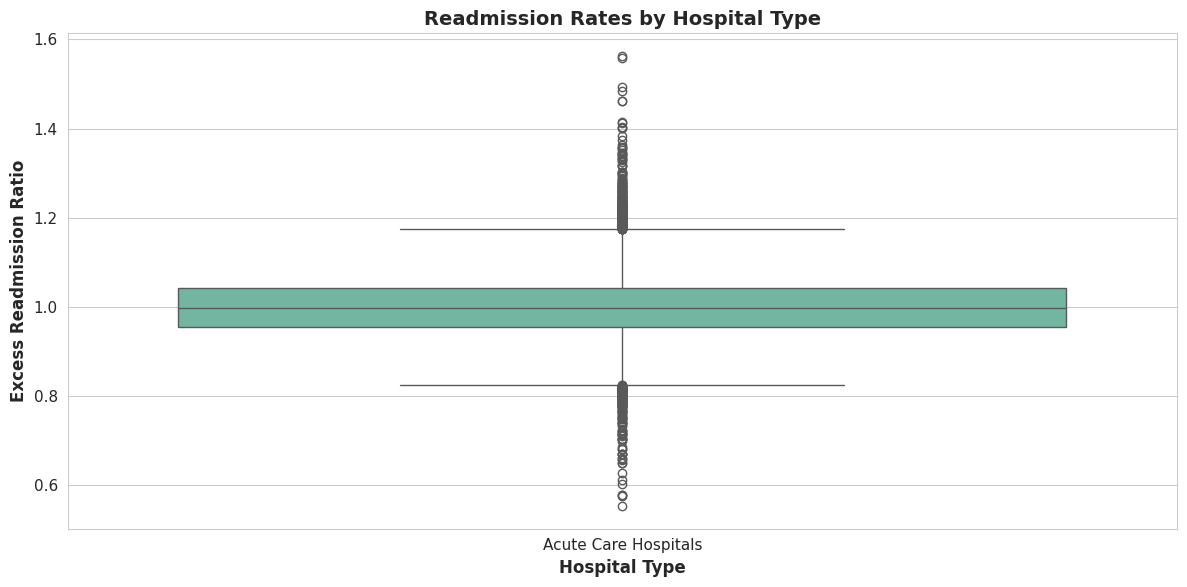

Figure saved: Figure2_Readmission_by_Type.png


In [11]:
# Figure 2: Box plot by hospital type "Acute"
if master_data is not None:

  # Locate the column that identifies hospital type within the dataset
    type_col = None
    for col in master_data.columns:
        if 'type' in col.lower() and 'hospital' in col.lower():
            type_col = col
            break

    if type_col and 'Excess Readmission Ratio' in master_data.columns:
        fig, ax = plt.subplots(figsize=(12, 6))

       # Filter out missing values before plotting
        data_plot = master_data[[type_col, 'Excess Readmission Ratio']].dropna()

       # Build and format the box plot with appropriate labels and styling
        sns.boxplot(data=data_plot, x=type_col, y='Excess Readmission Ratio', ax=ax, palette='Set2')
        ax.set_xlabel('Hospital Type', fontsize=12, fontweight='bold')
        ax.set_ylabel('Excess Readmission Ratio', fontsize=12, fontweight='bold')
        ax.set_title('Readmission Rates by Hospital Type', fontsize=14, fontweight='bold')
        plt.tight_layout()

        # Save the finalized figure as a high resolution image
        plt.savefig('Figure2_Readmission_by_Type.png', dpi=300, bbox_inches='tight')
        plt.show()

        print("Figure saved: Figure2_Readmission_by_Type.png")

# 7. Statistical Modeling


Build the facility-level classification pipeline. The target is high-risk status based on mean ERR >= 1.0; ERR-derived predictors are excluded from the feature matrix to reduce leakage. Candidate models include Logistic Regression, Random Forest, Gradient Boosting, SVM, XGBoost, EBM, and a stacking ensemble. Models are compared using stratified cross-validation and a hold-out test set.


In [12]:
# Build and evaluate machine learning models to identify hospitals at high risk of excessive readmissions
if master_data is not None and 'Excess Readmission Ratio' in master_data.columns:


    # Step 1: Locate the facility identifier column in the dataset                                 #

    def _find_id_col(df):
        for candidate in ['Hospital_ID', 'Provider_ID', 'Facility ID_readmit']:
            if candidate in df.columns:
                return candidate
        matches = [c for c in df.columns if 'Facility' in c or 'Provider' in c]
        if not matches:
            raise ValueError(
                "Cannot find a facility/provider ID column in master_data. "
                "Available columns: " + str(list(df.columns))
            )
        return matches[0]

    id_col    = _find_id_col(master_data)
    ratio_col = 'Excess Readmission Ratio'



    # Step 2: Collapse measure-level rows into one record per hospital

    # mean_ratio is computed ONLY to define the target (high_risk).

    agg_dict = {
        ratio_col:                 'mean',    # -> mean_ratio (target only)
        'Hospital Type':           'first',
        'Hospital Ownership':      'first',
        'Hospital overall rating': 'first',
    }
    if 'Emergency Services' in master_data.columns:
        agg_dict['Emergency Services'] = 'first'

    facility_name_candidates = [c for c in master_data.columns if 'Facility Name' in c]
    disp_name_col = facility_name_candidates[0] if facility_name_candidates else None
    if disp_name_col:
        agg_dict[disp_name_col] = 'first'

    facility = master_data.groupby(id_col).agg(agg_dict).reset_index()

    # Single-function agg -> flat columns, rename directly (no MultiIndex)
    facility = facility.rename(columns={ratio_col: 'mean_ratio'})


    # Step 2b: Attach patient experience scores from the HCAHPS dataset                           #

    if hcahps is not None and 'Facility ID' in hcahps.columns:
        hcahps_work = hcahps.copy()
        hcahps_work['HCAHPS_linear'] = pd.to_numeric(
            hcahps_work['HCAHPS Linear Mean Value'], errors='coerce'
        )
        hcahps_work['HCAHPS_star'] = pd.to_numeric(
            hcahps_work['Patient Survey Star Rating'], errors='coerce'
        )
        hcahps_fac = (
            hcahps_work.groupby('Facility ID')
            .agg({'HCAHPS_linear': 'mean', 'HCAHPS_star': 'mean'})
            .reset_index()
        )
        facility['_fid']   = facility[id_col].astype(str).str.lstrip('0')
        hcahps_fac['_fid'] = hcahps_fac['Facility ID'].astype(str).str.lstrip('0')
        facility = (
            facility
            .merge(hcahps_fac[['_fid', 'HCAHPS_linear', 'HCAHPS_star']], on='_fid', how='left')
            .drop(columns=['_fid'])
        )


   #Step 3: Define the binary target and assemble the feature matrix

    facility['high_risk'] = (facility['mean_ratio'] >= 1).astype(int)

    # Rating: keep both numeric and categorical versions
    facility['rating_num'] = pd.to_numeric(facility['Hospital overall rating'], errors='coerce')
    facility['rating_cat'] = facility['Hospital overall rating'].fillna('Not Available')

    # HCAHPS star: create an ordinal categorical with explicit "Not Available"
    if 'HCAHPS_star' in facility.columns:
        star_round = facility['HCAHPS_star'].round().astype('Int64')
        facility['HCAHPS_star_cat'] = star_round.astype(str).where(star_round.notna(), 'Not Available')

    # Define raw feature set (no manual imputation or dummies here)
    feature_cols = ['rating_cat', 'Hospital Type', 'Hospital Ownership']
    for c in ['Emergency Services', 'HCAHPS_linear', 'HCAHPS_star_cat']:
        if c in facility.columns:
            feature_cols.append(c)

    X = facility[[c for c in feature_cols if c in facility.columns]].copy()
    y = facility['high_risk']

    # Only HCAHPS_linear is treated as numeric here; rating is purely categorical
    num_cols = [c for c in ['HCAHPS_linear'] if c in X.columns]
    cat_cols = [c for c in ['Hospital Type', 'Hospital Ownership', 'Emergency Services', 'rating_cat', 'HCAHPS_star_cat'] if c in X.columns]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocess = ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ], remainder="drop")

    print("=" * 60)
    print("CLEAN MODEL - preprocessing inside pipeline (no ERR-derived features)")
    print("Raw features used:", list(X.columns))
    print("=" * 60)
    print(f"Raw feature table shape : {X.shape}")
    print(f"Facility-level N        : {len(X)}")
    print(f"High-risk (mean ERR>=1) : {y.sum()} ({100*y.mean():.1f}%)\n")


    # Step 4: Split data into training and held-out test sets

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )


   # Step 5: Set up a collection of candidate models with preprocessing

    pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

    base_models = {
        "LogisticRegression": LogisticRegression(
            max_iter=3000, solver="saga", class_weight="balanced"
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=200, max_depth=None, min_samples_leaf=2,
            class_weight="balanced", random_state=42
        ),
        "GradientBoosting": GradientBoostingClassifier(random_state=42),
        "SVM_RBF": SVC(
            kernel="rbf", C=1.0, gamma="scale",
            probability=True, class_weight="balanced", random_state=42
        ),
    }

    base_models["XGBoost"] = XGBClassifier(
            n_estimators=200, max_depth=6, eval_metric="logloss",
            scale_pos_weight=pos_weight, random_state=42
        )

    base_models["EBM"] = ExplainableBoostingClassifier(
            max_bins=256,
            interactions=5,
            learning_rate=0.01,
            random_state=42
        )

    stacking_base = [
        ("rf", RandomForestClassifier(
            n_estimators=100, class_weight="balanced", random_state=42
        )),
        ("gb", GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ("lr", LogisticRegression(max_iter=2000, solver="saga", class_weight="balanced")),
    ]
    stacking_base.append((
            "xgb",
            XGBClassifier(
                n_estimators=100, eval_metric="logloss",
                scale_pos_weight=pos_weight, random_state=42
            )
        ))

    base_models["Stacking"] = StackingClassifier(
        estimators=stacking_base,
        final_estimator=LogisticRegression(max_iter=2000, solver="saga", class_weight="balanced"),
        cv=5,
    )

    models = {
        name: Pipeline([("preprocess", preprocess), ("clf", mdl)])
        for name, mdl in base_models.items()
    }


   # Step 6: Evaluate all models using stratified cross validation

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    model_results = []

    print("5-fold stratified CV - train set only")
    print("=" * 70)

    for name, model in models.items():
        try:
            auc_scores = cross_val_score(
                model, X_train, y_train, cv=cv, scoring="roc_auc"
            )
            auc_mean, auc_std = auc_scores.mean(), auc_scores.std()
        except Exception as e:
            print(f"  AUC failed for {name}: {e}")
            auc_mean, auc_std = float("nan"), float("nan")

        acc_scores = cross_val_score(
            model, X_train, y_train, cv=cv, scoring="accuracy"
        )
        model_results.append({
            "Model":         name,
            "ROC_AUC_Mean":  auc_mean,
            "ROC_AUC_SD":    auc_std,
            "Accuracy_Mean": acc_scores.mean(),
            "Accuracy_SD":   acc_scores.std(),
        })

    model_results_df = (
        pd.DataFrame(model_results)
        .sort_values("ROC_AUC_Mean", ascending=False)
        .reset_index(drop=True)
    )
    print("Cross-validated performance (clean features):")
    display(model_results_df.round(3))


    # Step 7: Fine tune the best performing model on the training set

    best_name  = model_results_df.iloc[0]["Model"]
    best_model = models[best_name]

    param_grids = {
        "RandomForest": {
            "clf__n_estimators":     [150, 200],
            "clf__max_depth":        [10, 20, None],
            "clf__min_samples_leaf": [2, 5],
        },
        "GradientBoosting": {
            "clf__n_estimators":  [100, 200],
            "clf__max_depth":     [3, 5],
            "clf__learning_rate": [0.05, 0.1],
        },
        "XGBoost": {
            "clf__n_estimators":  [150, 200],
            "clf__max_depth":     [4, 6],
            "clf__learning_rate": [0.05, 0.1],
        },
        "LogisticRegression": {"clf__C": [0.01, 0.1, 1.0, 10.0]},
        "SVM_RBF":            {"clf__C": [0.5, 1.0, 2.0], "clf__gamma": ["scale", "auto"]},
        # EBM tuning - interactions and bins are the key levers
        "EBM": {
            "clf__max_bins":     [128, 256],
            "clf__interactions": [3, 5, 10],
            "clf__learning_rate": [0.005, 0.01, 0.05],
        },
    }

    if best_name in param_grids and len(X_train) > 100:
        print(f"\nTuning {best_name} (train set only)...")
        gs = GridSearchCV(
            best_model, param_grids[best_name],
            cv=3, scoring="roc_auc", n_jobs=-1, verbose=0
        )
        gs.fit(X_train, y_train)
        best_model = gs.best_estimator_
        print(f"Best params: {gs.best_params_}")
    else:
        best_model.fit(X_train, y_train)

    print(f"\nSelected model : {best_name}")
    print(f"CV Mean ROC-AUC: {model_results_df.iloc[0]['ROC_AUC_Mean']:.3f}  "
          f"| CV Mean Accuracy: {model_results_df.iloc[0]['Accuracy_Mean']:.3f}")


    # Step 8: Assess final model performance on the untouched test set

    y_pred = best_model.predict(X_test)
    if hasattr(best_model, "predict_proba"):
        y_prob = best_model.predict_proba(X_test)[:, 1]
    else:
        s = best_model.decision_function(X_test)
        y_prob = (s - s.min()) / (s.max() - s.min() + 1e-9)

    print(f"\nHold-out test performance ({best_name}) - CLEAN MODEL")
    print("=" * 55)
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"AUC-ROC  : {roc_auc_score(y_test, y_prob):.3f}")
    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=['Not high-risk', 'High-risk']))


   # Step 9: Extract and display feature importance for interpretability

    fi_df     = None
    estimator = best_model.named_steps['clf'] if hasattr(best_model, 'named_steps') else best_model

    # Try to get transformed feature names from the preprocessing pipeline
    transformed_feature_names = None
    if hasattr(best_model, 'named_steps') and 'preprocess' in best_model.named_steps:
        try:
            transformed_feature_names = best_model.named_steps['preprocess'].get_feature_names_out()
        except Exception:
            transformed_feature_names = None

    # EBM: glass-box explanation with per-feature mean absolute scores
    # and automatic pairwise interaction terms
    if isinstance(estimator, ExplainableBoostingClassifier):
        ebm_global  = estimator.explain_global()
        ebm_data    = ebm_global.data()
        fi_df = (
            pd.DataFrame({
                "Feature":    ebm_data['names'],
                "Importance": ebm_data['scores'],
            })
            .sort_values("Importance", ascending=False)
        )
        print("\nEBM Global Feature Importance (mean absolute contribution):")
        display(fi_df.round(4))

        # Separate individual features from detected interactions
        interactions_df = fi_df[fi_df['Feature'].str.contains(' x ', na=False)]
        if not interactions_df.empty:
            print("\nTop detected pairwise interactions (EBM):")
            display(interactions_df.round(4))

    # Tree-based models: native feature importances (uses transformed features)
    elif hasattr(estimator, "feature_importances_"):
        feat_names = transformed_feature_names
        if feat_names is None or len(feat_names) != len(estimator.feature_importances_):
            feat_names = [f"f{i}" for i in range(len(estimator.feature_importances_))]
        fi_df = (
            pd.DataFrame({
                "Feature":    feat_names,
                "Importance": estimator.feature_importances_,
            })
            .sort_values("Importance", ascending=False)
        )
        print("\nTop 10 features (tree importance):")
        display(fi_df.head(10).round(4))

    # Linear models: sorted coefficients (uses transformed features)
    elif hasattr(estimator, "coef_"):
        feat_names = transformed_feature_names
        if feat_names is None or len(feat_names) != len(estimator.coef_[0]):
            feat_names = [f"f{i}" for i in range(len(estimator.coef_[0]))]
        fi_df = (
            pd.DataFrame({
                "Feature":     feat_names,
                "Coefficient": estimator.coef_[0],
            })
            .assign(Abs_Coef=lambda d: d["Coefficient"].abs())
            .sort_values("Abs_Coef", ascending=False)
        )
        print("\nTop 10 features (|logistic coefficient|):")
        display(fi_df.head(10).round(4))

    # Stacking / SVM: model-agnostic permutation importance (raw columns)
    else:
        print(f"\n{best_name} - using permutation importance (raw columns)...")
        perm = permutation_importance(
            best_model, X_test, y_test,
            n_repeats=10, random_state=42, scoring="roc_auc"
        )
        fi_df = (
            pd.DataFrame({
                "Feature":         X_test.columns,
                "Importance_Mean": perm.importances_mean,
                "Importance_SD":   perm.importances_std,
            })
            .sort_values("Importance_Mean", ascending=False)
        )
        print("\nTop 10 features (permutation importance):")
        display(fi_df.head(10).round(4))

   # Step 10: Generate risk predictions for all hospitals and export

    best_model.fit(X, y)
    facility['pred_high_risk'] = best_model.predict(X)
    if hasattr(best_model, "predict_proba"):
        facility['pred_prob'] = best_model.predict_proba(X)[:, 1]

    disp_cols = [c for c in [id_col, 'mean_ratio', 'Hospital Type', 'Hospital Ownership',
                              'Hospital overall rating', 'pred_high_risk',
                              'pred_prob'] if c in facility.columns]
    if disp_name_col and disp_name_col in facility.columns:
        disp_cols = [disp_name_col] + disp_cols

    top_actual = facility.nlargest(20, 'mean_ratio')[disp_cols]
    print("\nTop 20 high-risk hospitals (by actual mean Excess Readmission Ratio):")
    print("=" * 55)
    display(top_actual)

    # Export all outputs
    facility.to_csv("facility_risk_scores.csv", index=False)
    model_results_df.to_csv("model_cv_results.csv", index=False)
    if fi_df is not None:
        fi_df.to_csv("feature_importance.csv", index=False)
    print("\nExported: facility_risk_scores.csv | model_cv_results.csv | feature_importance.csv")

    # Preserve for downstream cells
    best_model_name      = best_name
    facility_model_table = facility.copy()

else:
    print("master_data or 'Excess Readmission Ratio' column not found. Run data loading and merge first.")


CLEAN MODEL - preprocessing inside pipeline (no ERR-derived features)
Raw features used: ['rating_cat', 'Hospital Type', 'Hospital Ownership', 'Emergency Services', 'HCAHPS_linear', 'HCAHPS_star_cat']
Raw feature table shape : (2485, 6)
Facility-level N        : 2485
High-risk (mean ERR>=1) : 1145 (46.1%)

5-fold stratified CV - train set only
Cross-validated performance (clean features):


,Model,ROC_AUC_Mean,ROC_AUC_SD,Accuracy_Mean,Accuracy_SD
0,EBM,0.729,0.020,0.679,0.016
1,LogisticRegression,0.725,0.022,0.669,0.017
2,Stacking,0.722,0.018,0.665,0.011
3,GradientBoosting,0.710,0.023,0.664,0.016
4,SVM_RBF,0.707,0.020,0.673,0.015
5,RandomForest,0.688,0.015,0.640,0.014
6,XGBoost,0.657,0.012,0.630,0.016



Tuning EBM (train set only)...
Best params: {'clf__interactions': 5, 'clf__learning_rate': 0.05, 'clf__max_bins': 256}

Selected model : EBM
CV Mean ROC-AUC: 0.729  | CV Mean Accuracy: 0.679

Hold-out test performance (EBM) - CLEAN MODEL
Accuracy : 0.653
AUC-ROC  : 0.718

Confusion matrix:
[[274  61]
 [155 132]]

Classification report:
               precision    recall  f1-score   support

Not high-risk       0.64      0.82      0.72       335
    High-risk       0.68      0.46      0.55       287

     accuracy                           0.65       622
    macro avg       0.66      0.64      0.63       622
 weighted avg       0.66      0.65      0.64       622


EBM Global Feature Importance (mean absolute contribution):


,Feature,Importance
16,feature_0016,0.2318
15,feature_0015,0.1929
18,feature_0018,0.1684
20,feature_0020,0.1512
19,feature_0019,0.1384
22,feature_0022,0.1079
8,feature_0008,0.0944
1,feature_0001,0.0555
26,feature_0026,0.0554
0,feature_0000,0.0417



Top 20 high-risk hospitals (by actual mean Excess Readmission Ratio):


,Facility Name_readmit,Hospital_ID,mean_ratio,Hospital Type,Hospital Ownership,Hospital overall rating,pred_high_risk,pred_prob
687,CHRISTUS CENTRAL LOUISIANA SURGICAL HOSPITAL,190298,1.317000,Acute Care Hospitals,Proprietary,Not Available,0,0.236888
2144,BAYLOR SCOTT & WHITE MEDICAL CENTER - FRISCO,450853,1.257100,Acute Care Hospitals,Proprietary,2,1,0.663669
1868,DUNES SURGICAL HOSPITAL,430089,1.243300,Acute Care Hospitals,Proprietary,Not Available,0,0.266882
127,ST LUCIE MEDICAL CENTER,100260,1.221680,Acute Care Hospitals,Proprietary,1,1,0.866211
757,STURDY MEMORIAL HOSPITAL,220008,1.213950,Acute Care Hospitals,Voluntary non-profit - Other,3,0,0.482012
2450,CRESCENT MEDICAL CENTER LANCASTER,670090,1.198200,Acute Care Hospitals,Physician,4,0,0.272886
2443,BAYLOR SCOTT AND WHITE SURGICAL HOSPITAL AT SH...,670076,1.191200,Acute Care Hospitals,Physician,2,1,0.569531
3,ADVENTHEALTH ORLANDO,100007,1.165183,Acute Care Hospitals,Voluntary non-profit - Private,3,1,0.512384
48,BROWARD HEALTH NORTH,100086,1.164700,Acute Care Hospitals,Government - Hospital District or Authority,2,1,0.700828
1564,ALLIANCEHEALTH DURANT,370014,1.160160,Acute Care Hospitals,Proprietary,1,1,0.906039



Exported: facility_risk_scores.csv | model_cv_results.csv | feature_importance.csv


## 7.1 Trivial Baseline Comparators

Evaluate majority-class and stratified-random dummy classifiers on the same hold-out split used for the main models. These baselines define the performance floor for the classification task.


In [13]:
# -- Trivial Baselines (DummyClassifier) -----------------------------

if 'y_test' in dir() and 'y_train' in dir() and 'X_train' in dir() and 'X_test' in dir():

    baseline_rows = []
    for strategy, label in [
        ('most_frequent', 'Dummy_majority_class'),
        ('stratified', 'Dummy_stratified_random'),
    ]:
        dummy = DummyClassifier(strategy=strategy, random_state=42)
        dummy.fit(X_train, y_train)
        pred = dummy.predict(X_test)
        prob = dummy.predict_proba(X_test)[:, 1]
        baseline_rows.append({
            'Model': label,
            'Strategy': strategy,
            'Accuracy': accuracy_score(y_test, pred),
            'ROC_AUC': roc_auc_score(y_test, prob),
            'F1': f1_score(y_test, pred, zero_division=0),
        })

    baseline_trivial_df = pd.DataFrame(baseline_rows)

    print('=' * 60)
    print('TRIVIAL BASELINES - Hold-out Test Set (same split as Section 7)')
    print('=' * 60)
    display(baseline_trivial_df.round(3))

    if 'y_prob' in dir() and 'best_model_name' in dir():
        ref_auc = roc_auc_score(y_test, y_prob)
        print(f"\nReference - {best_model_name} (best ML model): ROC-AUC = {ref_auc:.3f}")
else:
    print('Run the modelling cell above first (requires y_train, y_test, X_train, X_test).')

TRIVIAL BASELINES - Hold-out Test Set (same split as Section 7)


,Model,Strategy,Accuracy,ROC_AUC,F1
0,Dummy_majority_class,most_frequent,0.539,0.500,0.000
1,Dummy_stratified_random,stratified,0.513,0.511,0.477



Reference - EBM (best ML model): ROC-AUC = 0.718


## 7.2 CMS Overall Star Rating Baseline

Fit a logistic regression using only CMS Hospital Overall Star Rating. This public quality metric is included as a simple policy-visible comparator; because CMS star ratings include readmission-related domains, results are interpreted as a comparator rather than an independent causal feature.


In [14]:
# -- CMS Star-Rating-Only Logistic Regression --------------------------
# Published/policy-style baseline: predict high_risk from Overall Star Rating alone

_split_vars = ['X_train', 'X_test', 'y_train', 'y_test']
_missing_split = [v for v in _split_vars if v not in globals()]

if not _missing_split:

    star_col = 'rating_cat'
    if star_col not in X_train.columns:
        print(f"'{star_col}' not in feature matrix - re-run the modelling cell above.")
    else:
        X_star_train = X_train[[star_col]].copy()
        X_star_test = X_test[[star_col]].copy()

        star_preprocess = ColumnTransformer([
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore')),
            ]), [star_col]),
        ], remainder='drop')

        star_lr = Pipeline([
            ('preprocess', star_preprocess),
            ('clf', LogisticRegression(
                max_iter=3000, solver='saga', class_weight='balanced', random_state=42
            )),
        ])
        star_lr.fit(X_star_train, y_train)

        star_pred = star_lr.predict(X_star_test)
        star_prob = star_lr.predict_proba(X_star_test)[:, 1]

        baseline_star_df = pd.DataFrame([{
            'Model': 'Logistic_CMS_star_only',
            'Features': star_col,
            'Accuracy': accuracy_score(y_test, star_pred),
            'ROC_AUC': roc_auc_score(y_test, star_prob),
            'F1': f1_score(y_test, star_pred, zero_division=0),
        }])

        print('=' * 60)
        print('POLICY BASELINE - CMS Overall Star Rating Only (hold-out test)')
        print('=' * 60)
        display(baseline_star_df.round(3))

        if 'baseline_trivial_df' in dir():
            baseline_comparison_df = pd.concat(
                [baseline_trivial_df, baseline_star_df], ignore_index=True
            )
            print('\nCombined trivial + star baselines:')
            display(baseline_comparison_df.round(3))

        if 'y_prob' in dir() and 'best_model_name' in dir():
            print(f"\nReference - {best_model_name}: ROC-AUC = {roc_auc_score(y_test, y_prob):.3f}")
else:
    print('Run the Section 7 modelling cell first (creates train/test split).')
    print('Missing in kernel:', _missing_split)

POLICY BASELINE - CMS Overall Star Rating Only (hold-out test)


,Model,Features,Accuracy,ROC_AUC,F1
0,Logistic_CMS_star_only,rating_cat,0.659,0.704,0.651



Combined trivial + star baselines:


,Model,Strategy,Accuracy,ROC_AUC,F1,Features
0,Dummy_majority_class,most_frequent,0.539,0.500,0.000,NaN
1,Dummy_stratified_random,stratified,0.513,0.511,0.477,NaN
2,Logistic_CMS_star_only,NaN,0.659,0.704,0.651,rating_cat



Reference - EBM: ROC-AUC = 0.718


## 7.3 Prior-Period ERR Audit and Same-Period ERR Rule

Audit whether the bundled CMS data include multiple reporting windows for a true prior-period ERR carry-forward baseline. When only one reporting window is available, evaluate a same-period rule that flags facilities with any HRRP measure ERR >= 1.0 and compare it on the hold-out split.


In [15]:
# -- Prior-Period ERR Check + Any-Measure ERR Rule Baseline -----------

if master_data is not None and 'Excess Readmission Ratio' in master_data.columns:

    ratio_col = 'Excess Readmission Ratio'
    start_col = 'Start Date' if 'Start Date' in master_data.columns else None
    end_col = 'End Date' if 'End Date' in master_data.columns else None

    if 'id_col' in dir():
        fid = id_col
    else:
        fid = None
        for candidate in ['Hospital_ID', 'Provider_ID', 'Facility ID_readmit', 'Facility ID']:
            if candidate in master_data.columns:
                fid = candidate
                break

    print('=' * 60)
    print('PRIOR-PERIOD ERR CARRY-FORWARD - DATA AUDIT')
    print('=' * 60)

    if start_col and end_col:
        periods = master_data[[start_col, end_col]].drop_duplicates().sort_values(start_col)
        n_periods = len(periods)
        display(periods.reset_index(drop=True))
    else:
        periods = pd.DataFrame()
        n_periods = 0
        print('Start Date / End Date not found in master_data.')

    print(f'\nUnique reporting periods: {n_periods}')

    baseline_carryforward_df = None

    if n_periods >= 2 and fid is not None:
        md = master_data.copy()
        md['_err'] = pd.to_numeric(md[ratio_col], errors='coerce')
        md['_period'] = md[start_col].astype(str) + ' | ' + md[end_col].astype(str)
        period_rank = (
            md[[start_col, end_col, '_period']]
            .drop_duplicates()
            .sort_values([start_col, end_col])
            .reset_index(drop=True)
        )
        period_rank['period_idx'] = np.arange(len(period_rank))
        md = md.merge(period_rank[['_period', 'period_idx']], on='_period', how='left')

        fac_period = (
            md.groupby([fid, 'period_idx'], as_index=False)['_err']
            .mean()
            .rename(columns={'_err': 'mean_err'})
        )
        fac_period['current_high'] = (fac_period['mean_err'] >= 1).astype(int)
        fac_period['prior_high'] = (
            fac_period.sort_values([fid, 'period_idx'])
            .groupby(fid)['mean_err']
            .shift(1)
            .ge(1)
        )

        latest_idx = fac_period['period_idx'].max()
        cf = fac_period[fac_period['period_idx'] == latest_idx].dropna(subset=['prior_high']).copy()
        cf['prior_high'] = cf['prior_high'].astype(int)

        if 'X_test' in dir() and 'facility' in dir():
            cf_map = cf.set_index(fid)['prior_high']
            rule_pred = facility[fid].map(cf_map)
            valid = rule_pred.notna() & facility.index.isin(X_test.index)
            y_cf = y_test.loc[valid]
            pred_cf = rule_pred.loc[valid].astype(int)
            prob_cf = pred_cf.astype(float)
            baseline_carryforward_df = pd.DataFrame([{
                'Model': 'Prior_period_ERR_carry_forward',
                'Features': 'prior reporting window',
                'Accuracy': accuracy_score(y_cf, pred_cf),
                'ROC_AUC': roc_auc_score(y_cf, prob_cf),
                'F1': f1_score(y_cf, pred_cf, zero_division=0),
            }])
            print('\nPrior-period carry-forward (hold-out facilities with prior window):')
            display(baseline_carryforward_df.round(3))
    else:
        print(
            '\nTrue prior-period carry-forward skipped: this dataset has a single CMS window.'
        )
        print(
            'Carry-forward requires a second Hospital_Readmissions.csv '
            'release; merge on Facility ID with non-overlapping Start/End dates.'
        )

    # Substitute: any measure ERR >= 1 (same reporting window, measure-level CMS rule)
    if fid is not None and 'X_test' in dir() and 'y_test' in dir() and 'facility' in dir():
        err_by_fac = (
            master_data.assign(_err=pd.to_numeric(master_data[ratio_col], errors='coerce'))
            .groupby(fid)['_err']
            .apply(lambda s: (s >= 1).any())
        )
        rule_any_high = facility[fid].map(err_by_fac).fillna(0).astype(int)

        rule_test = rule_any_high.loc[X_test.index]
        prob_rule = rule_test.astype(float)

        baseline_err_rule_df = pd.DataFrame([{
            'Model': 'Rule_any_measure_ERR_ge_1',
            'Features': 'measure-level ERR',
            'Accuracy': accuracy_score(y_test, rule_test),
            'ROC_AUC': roc_auc_score(y_test, prob_rule),
            'F1': f1_score(y_test, rule_test, zero_division=0),
        }])

        print('\n' + '=' * 60)
        print('CMS RULE SUBSTITUTE - Any Measure ERR >= 1 (hold-out test)')
        print('=' * 60)
        display(baseline_err_rule_df.round(3))

        parts = [
            df for df in [
                globals().get('baseline_trivial_df'),
                globals().get('baseline_star_df'),
                baseline_err_rule_df,
                baseline_carryforward_df,
            ]
            if df is not None
        ]
        if parts:
            baseline_comparison_df = pd.concat(parts, ignore_index=True)
            print('\nAll baselines collected so far:')
            display(baseline_comparison_df.round(3))

        if 'y_prob' in dir() and 'best_model_name' in dir():
            print(f"\nReference - {best_model_name}: ROC-AUC = {roc_auc_score(y_test, y_prob):.3f}")
    elif fid is None:
        print('Facility ID column not found - run data loading and modelling cells first.')
    else:
        print('Run the modelling cell above first (requires facility, X_test, y_test).')
else:
    print('Run data loading first (master_data with Excess Readmission Ratio required).')

PRIOR-PERIOD ERR CARRY-FORWARD - DATA AUDIT


,Start Date,End Date
0,07/01/2020,06/30/2023



Unique reporting periods: 1

True prior-period carry-forward skipped: this dataset has a single CMS window.
Carry-forward requires a second Hospital_Readmissions.csv release; merge on Facility ID with non-overlapping Start/End dates.

CMS RULE SUBSTITUTE - Any Measure ERR >= 1 (hold-out test)


,Model,Features,Accuracy,ROC_AUC,F1
0,Rule_any_measure_ERR_ge_1,measure-level ERR,0.686,0.709,0.746



All baselines collected so far:


,Model,Strategy,Accuracy,ROC_AUC,F1,Features
0,Dummy_majority_class,most_frequent,0.539,0.500,0.000,NaN
1,Dummy_stratified_random,stratified,0.513,0.511,0.477,NaN
2,Logistic_CMS_star_only,NaN,0.659,0.704,0.651,rating_cat
3,Rule_any_measure_ERR_ge_1,NaN,0.686,0.709,0.746,measure-level ERR



Reference - EBM: ROC-AUC = 0.718


## 7.4 Baseline Comparison Table

Combine trivial baselines, the CMS star-rating comparator, the ERR-rule comparator, Logistic Regression, and the selected interpretable model into one hold-out comparison table.


In [16]:
# -- Final Baseline Comparison + CSV Export ----------------------------

if 'y_test' in dir():

    def _holdout_metrics(model_name, y_true, pred, prob, features=''):
        row = {
            'Model': model_name,
            'Accuracy': accuracy_score(y_true, pred),
            'ROC_AUC': roc_auc_score(y_true, prob),
            'F1': f1_score(y_true, pred, zero_division=0),
        }
        if features:
            row['Features'] = features
        return row

    ml_rows = []
    feat_label = ', '.join(feature_cols) if 'feature_cols' in dir() else 'full pipeline'

    if all(v in globals() for v in ['y_pred', 'y_prob', 'best_model_name']):
        ml_rows.append(_holdout_metrics(
            best_model_name, y_test, y_pred, y_prob, feat_label
        ))

    if 'models' in dir() and 'LogisticRegression' in models:
        lr_pipe = models['LogisticRegression']
        lr_pipe.fit(X_train, y_train)
        lr_pred = lr_pipe.predict(X_test)
        if hasattr(lr_pipe, 'predict_proba'):
            lr_prob = lr_pipe.predict_proba(X_test)[:, 1]
        else:
            s = lr_pipe.decision_function(X_test)
            lr_prob = (s - s.min()) / (s.max() - s.min() + 1e-9)
        ml_rows.append(_holdout_metrics(
            'LogisticRegression (full features)', y_test, lr_pred, lr_prob, feat_label
        ))

    baseline_final_df = pd.DataFrame(ml_rows)

    if 'baseline_comparison_df' in dir():
        baseline_final_df = pd.concat(
            [baseline_comparison_df, baseline_final_df], ignore_index=True
        )
    else:
        parts = [
            globals().get('baseline_trivial_df'),
            globals().get('baseline_star_df'),
            globals().get('baseline_err_rule_df'),
            globals().get('baseline_carryforward_df'),
        ]
        parts = [p for p in parts if p is not None]
        if parts:
            baseline_final_df = pd.concat(parts + [baseline_final_df], ignore_index=True)

    if 'Model' in baseline_final_df.columns:
        baseline_final_df = baseline_final_df.drop_duplicates(subset=['Model'], keep='last')

    col_order = [c for c in ['Model', 'Features', 'Strategy', 'Accuracy', 'ROC_AUC', 'F1']
                 if c in baseline_final_df.columns]
    baseline_final_df = baseline_final_df[col_order]

    print('=' * 60)
    print('FINAL BASELINE COMPARISON - Hold-out Test Set (n = %d)' % len(y_test))
    print('=' * 60)
    display(baseline_final_df.round(3))

    baseline_final_df.to_csv('baseline_comparison.csv', index=False)
    print('\nExported: baseline_comparison.csv')

    if 'model_results_df' in dir() and 'best_model_name' in dir():
        cv_row = model_results_df.loc[model_results_df['Model'] == best_model_name]
        if not cv_row.empty:
            print(
                f"\n(CV reference) {best_model_name} 5-fold ROC-AUC mean: "
                f"{cv_row.iloc[0]['ROC_AUC_Mean']:.3f}"
            )

else:
    print('Run modelling and baseline cells (7.4-7.6) first.')

FINAL BASELINE COMPARISON - Hold-out Test Set (n = 622)


,Model,Features,Strategy,Accuracy,ROC_AUC,F1
0,Dummy_majority_class,NaN,most_frequent,0.539,0.500,0.000
1,Dummy_stratified_random,NaN,stratified,0.513,0.511,0.477
2,Logistic_CMS_star_only,rating_cat,NaN,0.659,0.704,0.651
3,Rule_any_measure_ERR_ge_1,measure-level ERR,NaN,0.686,0.709,0.746
4,EBM,"rating_cat, Hospital Type, Hospital Ownership,...",NaN,0.653,0.718,0.550
5,LogisticRegression (full features),"rating_cat, Hospital Type, Hospital Ownership,...",NaN,0.669,0.717,0.645



Exported: baseline_comparison.csv

(CV reference) EBM 5-fold ROC-AUC mean: 0.729


## 7.5 Hold-out Deployment Metrics

Report confusion matrix, precision, recall, F1, PR-AUC, Brier score, operating-threshold sensitivity, and a bootstrap AUC comparison between EBM and Logistic Regression.


In [17]:
# -- Deployment Metrics ------------------------------------------------


print("=" * 60)
print("DEPLOYMENT METRICS - EBM (Hold-out Test Set)")
print("=" * 60)

# -- 1. Confusion Matrix -------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix (threshold = 0.50):")
print(f"                 Predicted Low-Risk   Predicted High-Risk")
print(f"Actual Low-Risk       {tn:<20} {fp}")
print(f"Actual High-Risk      {fn:<20} {tp}")

# -- 2. Classification Report --------------------------------------------------
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low-Risk', 'High-Risk'], digits=3))

# -- 3. PR-AUC -----------------------------------------------------------------
pr_auc = average_precision_score(y_test, y_prob)
print(f"PR-AUC (Average Precision): {pr_auc:.3f}")

# -- 4. Brier Score (Calibration) ----------------------------------------------
brier = brier_score_loss(y_test, y_prob)
print(f"Brier Score (lower = better calibration): {brier:.3f}")

# -- 5. Operating Threshold Analysis ------------------------------------------
print(f"\nOperating Threshold Analysis:")
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Flagged %'}")
print("-" * 60)
for thresh in [0.40, 0.50, 0.60]:
    y_pred_t = (y_prob >= thresh).astype(int)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec  = recall_score(y_test, y_pred_t, zero_division=0)
    f1   = f1_score(y_test, y_pred_t, zero_division=0)
    flagged = y_pred_t.mean() * 100
    print(f"{thresh:<12.2f} {prec:<12.3f} {rec:<12.3f} {f1:<12.3f} {flagged:.1f}%")

# -- 6. DeLong-style Bootstrap AUC Comparison (EBM vs Logistic Regression) ----
print(f"\nBootstrap AUC Comparison (EBM vs Logistic Regression, n=1000 bootstraps):")

# Re-fit Logistic Regression on same train set for fair comparison

lr_model = models["LogisticRegression"]
lr_model.fit(X_train, y_train)
if hasattr(lr_model, "predict_proba"):
    lr_prob = lr_model.predict_proba(X_test)[:, 1]
else:
    s = lr_model.decision_function(X_test)
    lr_prob = (s - s.min()) / (s.max() - s.min() + 1e-9)

rng = np.random.default_rng(42)
n_boot = 1000
ebm_aucs, lr_aucs = [], []
for _ in range(n_boot):
    idx = rng.choice(len(y_test), size=len(y_test), replace=True)
    yt = np.array(y_test)[idx]
    if len(np.unique(yt)) < 2:
        continue
    ebm_aucs.append(roc_auc_score(yt, np.array(y_prob)[idx]))
    lr_aucs.append(roc_auc_score(yt, lr_prob[idx]))

ebm_ci = np.percentile(ebm_aucs, [2.5, 97.5])
lr_ci  = np.percentile(lr_aucs,  [2.5, 97.5])
diff   = np.array(ebm_aucs) - np.array(lr_aucs)
p_val  = min(np.mean(diff <= 0), np.mean(diff >= 0)) * 2

print(f"  EBM AUC: {np.mean(ebm_aucs):.3f}  95% CI [{ebm_ci[0]:.3f}, {ebm_ci[1]:.3f}]")
print(f"  LR  AUC: {np.mean(lr_aucs):.3f}  95% CI [{lr_ci[0]:.3f},  {lr_ci[1]:.3f}]")
print(f"  Bootstrap p-value (EBM vs LR): {p_val:.3f}")


DEPLOYMENT METRICS - EBM (Hold-out Test Set)

Confusion Matrix (threshold = 0.50):
                 Predicted Low-Risk   Predicted High-Risk
Actual Low-Risk       274                  61
Actual High-Risk      155                  132

Classification Report:
              precision    recall  f1-score   support

    Low-Risk      0.639     0.818     0.717       335
   High-Risk      0.684     0.460     0.550       287

    accuracy                          0.653       622
   macro avg      0.661     0.639     0.634       622
weighted avg      0.660     0.653     0.640       622

PR-AUC (Average Precision): 0.681
Brier Score (lower = better calibration): 0.213

Operating Threshold Analysis:
Threshold    Precision    Recall       F1           Flagged %
------------------------------------------------------------
0.40         0.611        0.700        0.653        52.9%
0.50         0.684        0.460        0.550        31.0%
0.60         0.732        0.362        0.485        22.8%

Boot

## 7.6 Sensitivity Analysis: CMS Star Rating Circularity

Repeat cross-validation after removing CMS Overall Star Rating while retaining HCAHPS patient-experience features. The AUC drop quantifies how much model performance depends on the composite CMS rating.


In [18]:
# -- Star Rating Circularity Ablation ----------------------------------
# CMS Overall Star Rating incorporates readmission metrics, creating potential circularity.
# This cell re-runs CV without rating_cat to test whether results hold up


print("=" * 60)
print("ABLATION: With vs Without CMS Overall Star Rating")
print("=" * 60)
print("Note: HCAHPS_star_cat (patient survey) is retained in both runs.")
print("Only rating_cat (CMS composite star) is removed.\n")

# -- Features WITHOUT rating_cat -----------------------------------------------
ablation_feature_cols = [c for c in feature_cols if c not in ['rating_cat']]

X_ablation = facility[[c for c in ablation_feature_cols if c in facility.columns]].copy()

num_cols_abl = [c for c in ['HCAHPS_linear'] if c in X_ablation.columns]
cat_cols_abl = [c for c in ['Hospital Type', 'Hospital Ownership',
                             'Emergency Services', 'HCAHPS_star_cat']
                if c in X_ablation.columns]


numeric_pipe_abl = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler",  StandardScaler()),
])
categorical_pipe_abl = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore")),
])
preprocess_abl = ColumnTransformer([
    ("num", numeric_pipe_abl, num_cols_abl),
    ("cat", categorical_pipe_abl, cat_cols_abl),
], remainder="drop")

# Rebuild model dict with the same candidate learners, excluding the CMS rating feature.
pos_weight_abl = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

base_models_abl = {
    "LogisticRegression": LogisticRegression(max_iter=3000, solver="saga", class_weight="balanced"),
    "RandomForest":       RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "GradientBoosting":   GradientBoostingClassifier(random_state=42),
    "SVM_RBF":            SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42),
}
base_models_abl["EBM"] = ExplainableBoostingClassifier(
        max_bins=256, interactions=5, learning_rate=0.01, random_state=42
    )

models_abl = {
    name: Pipeline([("preprocess", preprocess_abl), ("clf", mdl)])
    for name, mdl in base_models_abl.items()
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -- Run ablation CV -----------------------------------------------------------
X_train_abl = X_ablation.loc[X_train.index]

ablation_results = []
for name, model in models_abl.items():
    auc_scores = cross_val_score(model, X_train_abl, y_train, cv=cv, scoring="roc_auc")
    ablation_results.append({
        "Model":            name,
        "AUC_with_rating":  model_results_df.set_index("Model").loc[name, "ROC_AUC_Mean"]
                            if name in model_results_df["Model"].values else None,
        "AUC_without_rating": auc_scores.mean(),
        "AUC_drop":         (model_results_df.set_index("Model").loc[name, "ROC_AUC_Mean"]
                            if name in model_results_df["Model"].values else np.nan)
                            - auc_scores.mean(),
    })

ablation_df = pd.DataFrame(ablation_results).sort_values("AUC_with_rating", ascending=False)
print("AUC Comparison - With vs Without CMS Overall Star Rating:")
print(ablation_df.round(4).to_string(index=False))

ablation_df.to_csv("ablation_no_star_rating.csv", index=False)
print("\nSaved: ablation_no_star_rating.csv")

ABLATION: With vs Without CMS Overall Star Rating
Note: HCAHPS_star_cat (patient survey) is retained in both runs.
Only rating_cat (CMS composite star) is removed.

AUC Comparison - With vs Without CMS Overall Star Rating:
             Model  AUC_with_rating  AUC_without_rating  AUC_drop
               EBM           0.7290              0.6606    0.0684
LogisticRegression           0.7249              0.6557    0.0692
  GradientBoosting           0.7104              0.6420    0.0684
           SVM_RBF           0.7068              0.6436    0.0632
      RandomForest           0.6877              0.6050    0.0827

Saved: ablation_no_star_rating.csv


## 7.7 EBM Shape Functions and Feature Contributions

Extract EBM global feature contributions, map transformed feature names to readable labels, and generate manuscript figures for the top shape functions and strongest detected interaction.


EBM SHAPE FUNCTIONS - READABLE FEATURE NAMES

Preprocessor output features (27 total):
  feature_0000  ->  num__HCAHPS_linear
  feature_0001  ->  num__missingindicator_HCAHPS_linear
  feature_0002  ->  cat__Hospital Type_Acute Care Hospitals
  feature_0003  ->  cat__Hospital Ownership_Government - Federal
  feature_0004  ->  cat__Hospital Ownership_Government - Hospital District or Authority
  feature_0005  ->  cat__Hospital Ownership_Government - Local
  feature_0006  ->  cat__Hospital Ownership_Government - State
  feature_0007  ->  cat__Hospital Ownership_Physician
  feature_0008  ->  cat__Hospital Ownership_Proprietary
  feature_0009  ->  cat__Hospital Ownership_Tribal
  feature_0010  ->  cat__Hospital Ownership_Voluntary non-profit - Church
  feature_0011  ->  cat__Hospital Ownership_Voluntary non-profit - Other
  feature_0012  ->  cat__Hospital Ownership_Voluntary non-profit - Private
  feature_0013  ->  cat__Emergency Services_No
  feature_0014  ->  cat__Emergency Services_Yes
 

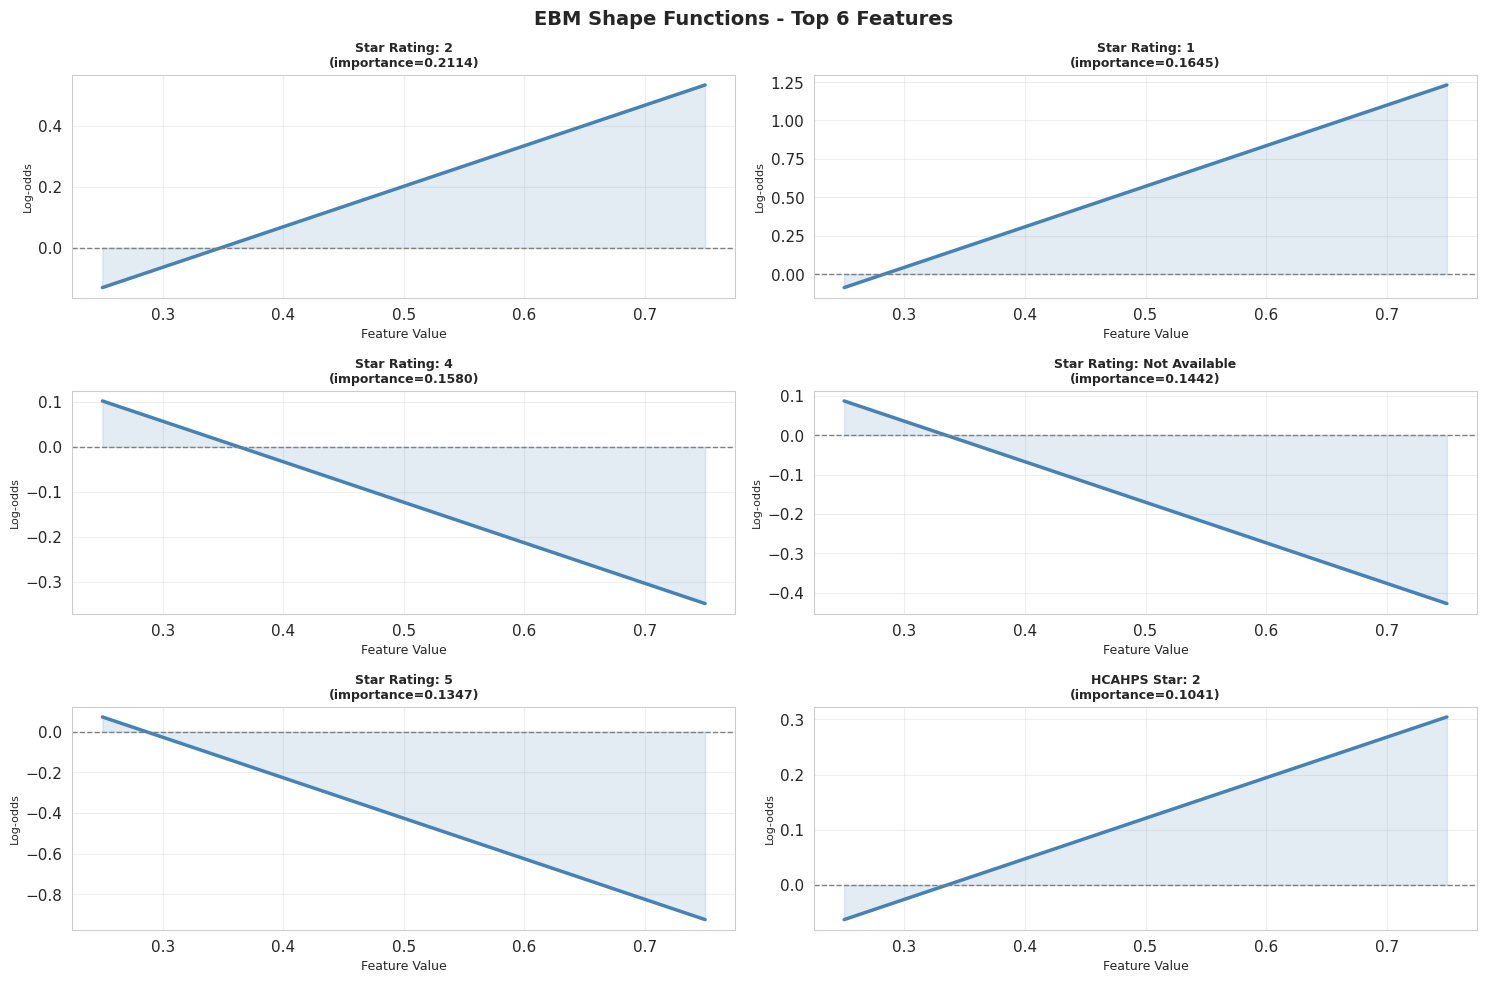

Saved: Figure5_EBM_Shape_Functions.png

Plotting top interaction: HCAHPS Satisfaction Score & Star Rating: 1


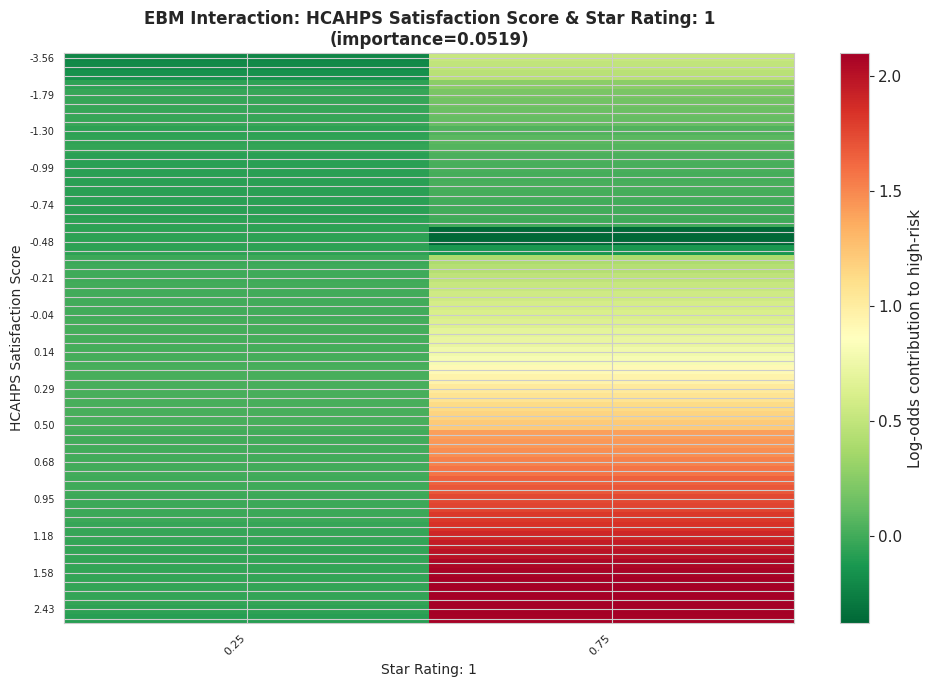

Saved: Figure6_EBM_Interaction.png


In [19]:
# -- EBM Shape Functions with Real Feature Names ---------------


print("=" * 60)
print("EBM SHAPE FUNCTIONS - READABLE FEATURE NAMES")
print("=" * 60)

# -- Step 5a: Extract real feature names from the preprocessor -----------------
try:
    raw_feature_names = best_model.named_steps['preprocess'].get_feature_names_out()
    print(f"\nPreprocessor output features ({len(raw_feature_names)} total):")
    for i, n in enumerate(raw_feature_names):
        print(f"  feature_{i:04d}  ->  {n}")
except Exception as e:
    print(f"Could not get feature names: {e}")
    raw_feature_names = [f"feature_{i:04d}" for i in range(100)]

# Build mapping: feature_0000 -> clean readable name
def clean_name(raw):
    raw = str(raw)
    raw = raw.replace("num__", "").replace("cat__", "")
    raw = raw.replace("missingindicator_0", "(missing flag)")
    raw = raw.replace("Hospital Ownership_", "Ownership: ")
    raw = raw.replace("Hospital Type_", "Type: ")
    raw = raw.replace("Emergency Services_", "Emergency: ")
    raw = raw.replace("rating_cat_", "Star Rating: ")
    raw = raw.replace("HCAHPS_star_cat_", "HCAHPS Star: ")
    raw = raw.replace("HCAHPS_linear", "HCAHPS Satisfaction Score")
    return raw

feature_name_map = {
    f"feature_{i:04d}": clean_name(n)
    for i, n in enumerate(raw_feature_names)
}

def map_ebm_term_name(term):
    """Map placeholder names to readable labels; pairwise terms use `` & ``."""
    term = str(term)
    sep = " & "
    if sep in term:
        return sep.join(
            feature_name_map.get(side.strip(), side.strip())
            for side in term.split(sep)
        )
    return feature_name_map.get(term.strip(), term)

# -- Step 5b: Get EBM global explanation --------------------------------------
ebm_estimator = best_model.named_steps['clf']
ebm_global    = ebm_estimator.explain_global()
ebm_data      = ebm_global.data()

names  = [map_ebm_term_name(n) for n in ebm_data['names']]
scores = ebm_data['scores']

print("\nTop EBM terms with real names:")
sorted_terms = sorted(zip(range(len(names)), names, scores), key=lambda x: x[2], reverse=True)
feature_importance_df = pd.DataFrame(
    [{"Feature": n, "Importance": s} for _, n, s in sorted_terms]
)
feature_importance_df.to_csv("feature_importance.csv", index=False)
for i, n, s in sorted_terms[:15]:
    print(f"  [{i:2d}] {n:<55} importance={s:.4f}")
print("Saved: feature_importance.csv")

# -- Step 5c: Select top 6 individual features ---------------------------------
individual = [(i, n, s) for i, n, s in sorted_terms if '&' not in str(ebm_data['names'][i])][:6]
interactions = [(i, n, s) for i, n, s in sorted_terms if '&' in str(ebm_data['names'][i])]

# -- Step 5d: Plot shape functions ---------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()

for plot_idx, (term_idx, term_name, term_score) in enumerate(individual):
    ax = axes[plot_idx]
    try:
        td      = ebm_global.data(term_idx)
        scores_t = np.array(td.get('scores', td.get('values', [])))
        names_t  = td.get('names', td.get('left_names', []))

        if len(scores_t) == 0:
            ax.set_title(f"{term_name}\n(no data)", fontsize=9)
            continue

        # Continuous: names has n+1 bin edges, scores has n values -> use midpoints
        if isinstance(names_t[0], (int, float, np.floating, np.integer)):
            edges  = np.array(names_t, dtype=float)
            if len(edges) == len(scores_t) + 1:
                x_vals = (edges[:-1] + edges[1:]) / 2   # bin midpoints
            else:
                x_vals = edges[:len(scores_t)]
            ax.plot(x_vals, scores_t, color='steelblue', linewidth=2.5)
            ax.fill_between(x_vals, 0, scores_t, alpha=0.15, color='steelblue')
            ax.axhline(0, color='gray', linestyle='--', linewidth=1)
            ax.set_xlabel("Feature Value", fontsize=9)

        else:
            # Categorical: bar chart
            labels = [str(v) for v in names_t[:len(scores_t)]]
            colors = ['tomato' if v > 0 else 'steelblue' for v in scores_t]
            ax.barh(range(len(labels)), scores_t, color=colors)
            ax.set_yticks(range(len(labels)))
            ax.set_yticklabels(labels, fontsize=7)
            ax.axvline(0, color='gray', linestyle='--', linewidth=1)
            ax.set_xlabel("Log-odds contribution", fontsize=9)

        ax.set_title(f"{term_name}\n(importance={term_score:.4f})", fontsize=9, fontweight='bold')
        ax.set_ylabel("Log-odds", fontsize=8)
        ax.grid(True, alpha=0.3)

    except Exception as e:
        ax.set_title(f"{term_name}\n(err: {e})", fontsize=7)

plt.suptitle("EBM Shape Functions - Top 6 Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure5_EBM_Shape_Functions.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: Figure5_EBM_Shape_Functions.png")

# -- Step 5e: Top interaction heatmap -----------------------------------------
if interactions:
    top_idx, top_name, top_score = interactions[0]
    print(f"\nPlotting top interaction: {top_name}")
    try:
        int_d      = ebm_global.data(top_idx)
        z          = np.array(int_d.get('scores', int_d.get('values', [])))
        left_raw   = int_d.get('left_names',  int_d.get('names', []))
        right_raw  = int_d.get('right_names', [])

        # For continuous axes: use midpoints of bin edges
        def to_labels(arr, max_labels=10):
            arr = list(arr)
            if len(arr) == 0:
                return []
            if isinstance(arr[0], (int, float, np.floating, np.integer)):
                edges = np.array(arr, dtype=float)
                mids  = (edges[:-1] + edges[1:]) / 2 if len(edges) > 1 else edges
                step  = max(1, len(mids) // max_labels)
                return [f"{v:.2f}" if i % step == 0 else "" for i, v in enumerate(mids)]
            else:
                return [str(v) for v in arr]

        if z.ndim == 2:
            row_labels = to_labels(left_raw,  max_labels=15)
            col_labels = to_labels(right_raw, max_labels=8)

            # Trim z to match label counts
            n_rows = len(row_labels) if row_labels else z.shape[0]
            n_cols = len(col_labels) if col_labels else z.shape[1]
            z_plot = z[:n_rows, :n_cols]

            fig2, ax2 = plt.subplots(figsize=(10, 7))
            im = ax2.imshow(z_plot, cmap='RdYlGn_r', aspect='auto')
            ax2.set_xticks(range(len(col_labels)))
            ax2.set_xticklabels(col_labels, rotation=45, ha='right', fontsize=8)
            ax2.set_yticks(range(len(row_labels)))
            ax2.set_yticklabels(row_labels, fontsize=7)
            plt.colorbar(im, ax=ax2, label='Log-odds contribution to high-risk')
            ax2.set_title(f"EBM Interaction: {top_name}\n(importance={top_score:.4f})",
                          fontsize=12, fontweight='bold')
            # Extract the two feature names for axis labels
            parts = top_name.split(' & ')
            ax2.set_ylabel(parts[0] if len(parts) > 0 else "Feature 1", fontsize=10)
            ax2.set_xlabel(parts[1] if len(parts) > 1 else "Feature 2", fontsize=10)
            plt.tight_layout()
            plt.savefig("Figure6_EBM_Interaction.png", dpi=300, bbox_inches='tight')
            plt.show()
            print("Saved: Figure6_EBM_Interaction.png")
        else:
            print(f"Unexpected z shape: {z.shape}")
    except Exception as e:
        print(f"Interaction plot error: {e}")

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 7.8 Correlation Analysis


Construct a facility-level correlation matrix to examine relationships among hospital quality metrics, patient-experience features, and the high-risk readmission target. The resulting heatmap is saved as a manuscript figure.


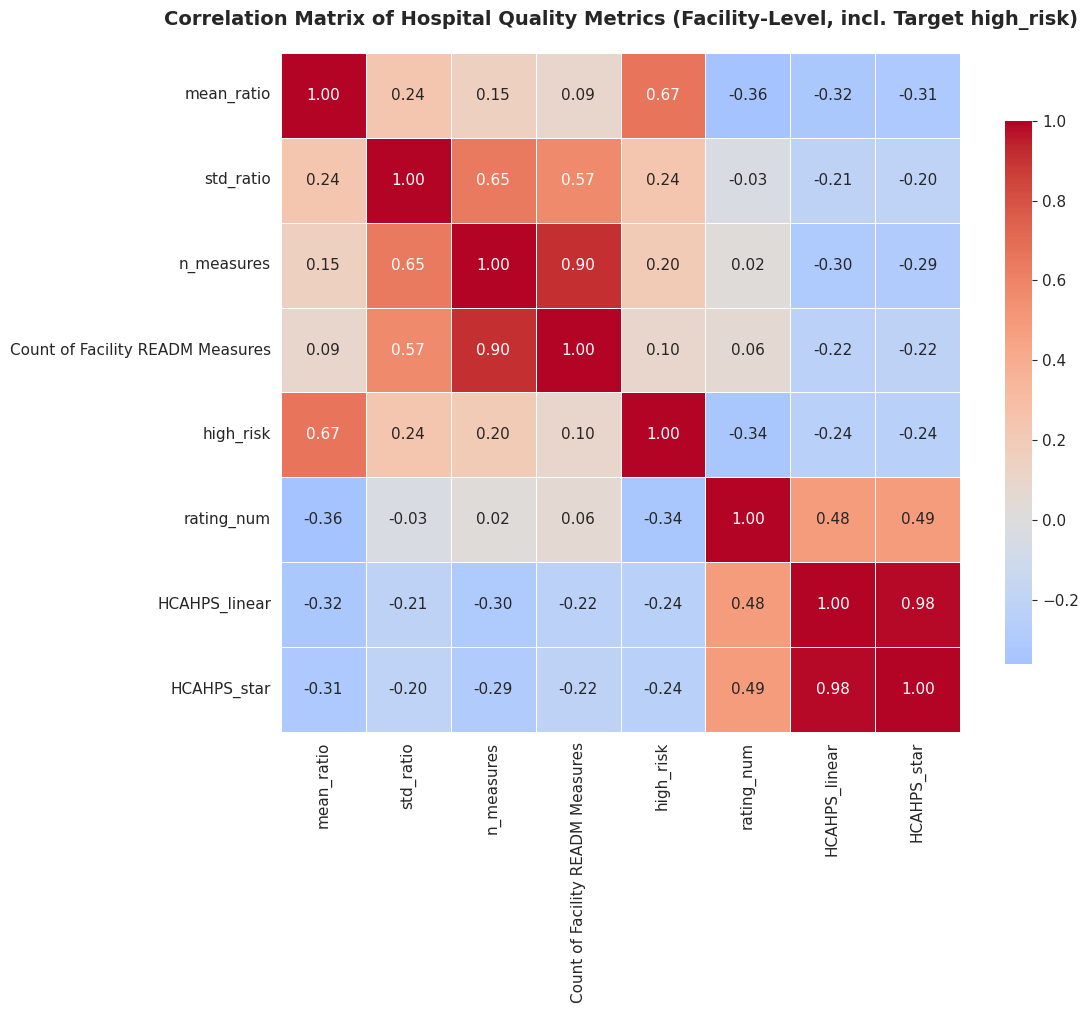

Figure saved: Figure3_Correlation_Matrix.png
Includes target 'high_risk' and 8 numeric variables at facility level.


In [20]:
# Construct a facility level correlation matrix including the high risk target variable
if master_data is not None and 'Excess Readmission Ratio' in master_data.columns:

    # Locate the column that uniquely identifies each hospital facility
    id_col = next((c for c in ['Hospital_ID', 'Provider_ID', 'Facility ID_readmit'] if c in master_data.columns), None)
    if id_col is None:
        id_col = [c for c in master_data.columns if 'Facility' in c or 'Provider' in c][0]

    ratio_col = 'Excess Readmission Ratio'
    agg_dict = {
        ratio_col: ['mean', 'std', 'count'],
        'Hospital Type': 'first',
        'Hospital Ownership': 'first',
        'Hospital overall rating': 'first',
    }
    for c in ['Emergency Services', 'Count of Facility READM Measures']:
        if c in master_data.columns:
            agg_dict[c] = 'first'

    facility_corr = master_data.groupby(id_col).agg(agg_dict).reset_index()

   # Flatten any multi level column headers into clean single level names
    new_cols = []
    for c in facility_corr.columns:
        if isinstance(c, tuple) and len(c) == 2:
            new_cols.append(f'{c[0]}_{c[1]}' if c[1] else str(c[0]))
        else:
            new_cols.append(str(c))
    facility_corr.columns = new_cols
    facility_corr = facility_corr.rename(columns={
        f'{ratio_col}_mean': 'mean_ratio',
        f'{ratio_col}_std': 'std_ratio',
        f'{ratio_col}_count': 'n_measures',
    })
    facility_corr = facility_corr.rename(columns={c: c.replace('_first', '') for c in facility_corr.columns if '_first' in c})

      # Assign the binary high risk label based on mean readmission ratio threshold
    facility_corr['high_risk'] = (facility_corr['mean_ratio'] >= 1).astype(int)

    # Numeric columns for correlation
    facility_corr['rating_num'] = pd.to_numeric(facility_corr['Hospital overall rating'], errors='coerce')
    facility_corr['rating_num'] = facility_corr['rating_num'].fillna(facility_corr['rating_num'].median())
    facility_corr['std_ratio'] = facility_corr['std_ratio'].fillna(0)
    if 'Count of Facility READM Measures' in facility_corr.columns:
        facility_corr['Count of Facility READM Measures'] = pd.to_numeric(facility_corr['Count of Facility READM Measures'], errors='coerce')

    # Merge HCAHPS if available (same as ML section)
    hcahps_var = globals().get('hcahps')
    if hcahps_var is not None and 'Facility ID' in hcahps_var.columns:
        hcahps_work = hcahps_var.copy()
        hcahps_work['HCAHPS_linear'] = pd.to_numeric(hcahps_work['HCAHPS Linear Mean Value'], errors='coerce')
        hcahps_work['HCAHPS_star'] = pd.to_numeric(hcahps_work['Patient Survey Star Rating'], errors='coerce')
        hcahps_fac = hcahps_work.groupby('Facility ID').agg({'HCAHPS_linear': 'mean', 'HCAHPS_star': 'mean'}).reset_index()
        facility_corr['_fid'] = facility_corr[id_col].astype(str).str.lstrip('0')
        hcahps_fac['_fid'] = hcahps_fac['Facility ID'].astype(str).str.lstrip('0')
        facility_corr = facility_corr.merge(hcahps_fac[['_fid', 'HCAHPS_linear', 'HCAHPS_star']], on='_fid', how='left').drop(columns=['_fid'])
        facility_corr['HCAHPS_linear'] = facility_corr['HCAHPS_linear'].fillna(facility_corr['HCAHPS_linear'].median())
        facility_corr['HCAHPS_star'] = facility_corr['HCAHPS_star'].fillna(facility_corr['HCAHPS_star'].median())

    # Select numeric columns (includes high_risk)
    numeric_cols = facility_corr.select_dtypes(include=[np.number]).columns.tolist()

    if len(numeric_cols) > 1:
        corr_matrix = facility_corr[numeric_cols].corr()

        # Plot heatmap
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                   fmt='.2f', square=True, linewidths=0.5, ax=ax,
                   cbar_kws={"shrink": 0.8})
        ax.set_title('Correlation Matrix of Hospital Quality Metrics (Facility-Level, incl. Target high_risk)',
                    fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.savefig('Figure3_Correlation_Matrix.png', dpi=300, bbox_inches='tight')
        plt.show()

        print("Figure saved: Figure3_Correlation_Matrix.png")
        print(f"Includes target 'high_risk' and {len(numeric_cols)} numeric variables at facility level.")

# 8. Export Results for Publication

Export manuscript-ready descriptive statistics, missingness summaries, model comparisons, feature importances, and facility-level risk predictions to an Excel workbook.


In [21]:
def export_analysis_results(
    master_data,
    model_results_df=None,
    best_model_name=None,
    feature_importance_df=None,
    facility_model_table=None,
    output_filename='CMS_Analysis_Results.xlsx'
):
    """Export all analysis results to Excel (including ML model outputs, if provided)."""

    if master_data is None:
        print("No data to export")
        return

    with pd.ExcelWriter(output_filename, engine='openpyxl') as writer:
        # Compute and save summary statistics for all numeric columns
        numeric_cols = master_data.select_dtypes(include=[np.number]).columns
        desc_stats = master_data[numeric_cols].describe().T
        desc_stats.to_excel(writer, sheet_name='Descriptive_Statistics')

        # Save the first 100 rows as a representative sample of the raw dataset
        master_data.head(100).to_excel(writer, sheet_name='Data_Sample', index=False)

        # Calculate and record the count and percentage of missing values per column
        missing_data = pd.DataFrame({
            'Column': master_data.columns,
            'Missing_Count': master_data.isnull().sum().values,
            'Missing_Percent': (master_data.isnull().sum() / len(master_data) * 100).values
        }).sort_values('Missing_Count', ascending=False)
        missing_data.to_excel(writer, sheet_name='Missing_Data', index=False)

        # Model comparison results and flag the best performing model
        if model_results_df is not None:
            df_to_save = model_results_df.copy()
            if best_model_name is not None and 'Model' in df_to_save.columns:
                df_to_save['Best_Model_Flag'] = (df_to_save['Model'] == best_model_name).astype(int)
            df_to_save.to_excel(writer, sheet_name='Model_Comparison', index=False)

        # Record feature importance or coefficient rankings from the selected model
        if feature_importance_df is not None:
            feature_importance_df.to_excel(writer, sheet_name='Model_Features', index=False)

        # Save hospital level risk predictions and relevant facility attributes
        if facility_model_table is not None:
            cols = [
                c for c in facility_model_table.columns
                if any(k in c for k in [
                    'Facility', 'Hospital_ID', 'mean_ratio', 'max_ratio', 'std_ratio', 'n_measures', 'n_high',
                    'Hospital Type', 'Hospital Ownership', 'Emergency Services',
                    'Hospital overall rating', 'pred_high_risk', 'pred_prob', 'HCAHPS'
                ])
            ]
            seen = set()
            cols_unique = []
            for c in cols:
                if c not in seen:
                    seen.add(c)
                    cols_unique.append(c)
            facility_model_table[cols_unique].to_excel(
                writer,
                sheet_name='High_Risk_Hospitals',
                index=False,
            )

        print(f"Results exported to {output_filename}")
        sheets = ['Descriptive_Statistics', 'Data_Sample', 'Missing_Data']
        if model_results_df is not None:
            sheets.append('Model_Comparison')
        if feature_importance_df is not None:
            sheets.append('Model_Features')
        if facility_model_table is not None:
            sheets.append('High_Risk_Hospitals')
        print(f"Sheets created: {', '.join(sheets)}")

# Export results
export_analysis_results(
    master_data,
    model_results_df=model_results_df if 'model_results_df' in globals() else None,
    best_model_name=best_model_name if 'best_model_name' in globals() else None,
    feature_importance_df=feature_importance_df if 'feature_importance_df' in globals() else None,
    facility_model_table=facility_model_table if 'facility_model_table' in globals() else None,
    output_filename='CMS_Research_Analysis_Results.xlsx',
)


Results exported to CMS_Research_Analysis_Results.xlsx
Sheets created: Descriptive_Statistics, Data_Sample, Missing_Data, Model_Comparison, Model_Features, High_Risk_Hospitals


# Summary

This notebook reproduces the analysis reported in the manuscript. Public CMS hospital datasets are loaded, cleaned, merged, and aggregated to the facility level. The primary target is high-risk readmission status, defined by mean ERR >= 1.0.

The descriptive analysis characterizes readmission variation by clinical measure, hospital type, ownership, star rating, and reporting period. The modeling section compares several supervised classifiers and emphasizes EBM because it balances discrimination with transparent feature contributions.

The final workflow exports figures and tables used for reporting, including model comparison, baseline comparator results, threshold sensitivity, star-rating ablation, EBM interpretability plots, and facility-level risk predictions.

Key manuscript conclusion: publicly available CMS attributes and patient-experience measures can support interpretable facility-level screening for excess readmission risk. The model should be interpreted as a public-data risk stratification tool, with limitations from CMS low-volume suppression, potential star-rating circularity, and the absence of patient-level EHR or claims variables.


# References and Data Sources

Primary data sources:

1. Centers for Medicare & Medicaid Services. Hospital Provider Data. https://data.cms.gov/provider-data/topics/hospitals
2. CMS Hospital Readmissions Reduction Program. https://www.cms.gov/medicare/payment/prospective-payment-systems/acute-inpatient-pps/hospital-readmissions-reduction-program-hrrp
3. Hospital Readmissions Reduction Program dataset. https://data.cms.gov/provider-data/dataset/9n3s-kdb3
4. Hospital General Information dataset. https://data.cms.gov/provider-data/dataset/xubh-q36u
5. HCAHPS Patient Survey. https://data.cms.gov/provider-data/topics/hospitals/hcahps
6. Healthcare-Associated Infections dataset. https://data.cms.gov/provider-data/dataset/77hc-ibv8
7. Complications and Deaths dataset. https://data.cms.gov/provider-data/dataset/ynj2-r877

Selected manuscript references:

1. Jencks SF, Williams MV, Coleman EA. Rehospitalizations among patients in the Medicare fee-for-service program. *N Engl J Med*. 2009;360(14):1418-1428.
2. Krumholz HM. Post-hospital syndrome: an acquired, transient condition of generalized risk. *N Engl J Med*. 2013;368(2):100-102.
3. Horwitz LI, Partovian C, Lin Z, Herrin J, Conover M, Montague J, et al. Development and use of an administrative claims measure for profiling hospital-wide readmission rates. *Circ Cardiovasc Qual Outcomes*. 2011;4(2):243-252.
4. Joynt KE, Jha AK. Characteristics of hospitals receiving penalties under the Hospital Readmissions Reduction Program. *JAMA*. 2012;308(12):265-267.
5. Frizzell JD, Liang L, Schulte PJ, Yancy CW, Heidenreich PA, Hernandez AF, et al. Prediction of 30-day all-cause readmissions in patients hospitalized for heart failure. *JAMA Cardiol*. 2017;2(2):204-209.
6. Molnar C. *Interpretable Machine Learning*. 2020. https://christophmolnar.com/books/interpretable-machine-learning/
7. Partnership for Quality Measurement. Hospital-Wide All-Cause Unplanned Readmission Measure (HWR), CBE #1789. https://p4qm.org/measures/1789
